In [1]:
# | Relation                        | Type IDs   |
# | ------------------------------- | ---------- |
# | บุคคลเดียวกัน (Same Person)        | 1, 2, 5, 7 |
# | บุคคลต่างกัน (Different Person)    | 3, 4, 6, 8 |

# ไฟล์ชุด base (ก่อน unlearning) = calculated_distances_effnet_base_8type.csv
# ไฟล์ชุด unlearning (หลัง unlearning) = type8_combined_calculated_distances.csv

# 🎯 สิ่งที่ต้องการสร้าง (4 ตัวแปร)

# same_after
# ระยะห่างของ “บุคคลเดียวกัน” หลังทำ unlearning
# → จากไฟล์ unlearning (EffNet หลัง unlearn)

# same_before
# ระยะห่างของ “บุคคลเดียวกัน” ก่อนทำ unlearning
# → จากไฟล์ base (EffNet ปกติ)

# diff_after
# ระยะห่างของ “บุคคลต่างกัน” หลังทำ unlearning

# diff_before
# ระยะห่างของ “บุคคลต่างกัน” ก่อนทำ unlearning

In [2]:
import pandas as pd

# -----------------------------------------
# โหลดไฟล์ CSV ทั้ง 2 แบบ
# -----------------------------------------
base_file = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/calculated_distances_effnet_base_8type.csv"
unlearn_file0 = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/type8_combined_calculated_distances.csv"
unlearn_file1 ="/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/combined_calculated_distances.csv"
df_before = pd.read_csv(base_file)       # EffNet ธรรมดา (before unlearning)
df_after0 = pd.read_csv(unlearn_file0)     # EffNet unlearned (after unlearning)
df_after1 = pd.read_csv(unlearn_file1) 
df_after = df_after0.append(df_after1)

# -----------------------------------------
# กำหนด Type ID แบ่งเป็น same/diff
# -----------------------------------------
# same_types = [1, 2, 5, 7]
diff_types = [3, 4, 6, 8]

In [22]:
df_after_diff_types = df_after[df_after["type"].isin(diff_types)]

df_before_diff_types = df_before[df_before["type"].isin(diff_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_diff_types = after.merge(before, on=['path_img1','path_img2'], how='left')

df_merged_diff_types

,path_img1,path_img2,distance_after,distance_before
0,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.476645,0.103627
1,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.333771,1.379364
2,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.211927,0.633022
3,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.350853,0.121601
4,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.454608,0.501347
...,...,...,...,...
406042,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.619571,1.284732
406043,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.324993,0.932543
406044,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.551648,0.974819
406045,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,/media/HDD/tripletloss_dataset/CelebA/7_type/t...,1.291946,0.313818


In [4]:
# df_after_same_types = df_after[df_after["type"].isin(same_types)]

# df_before_same_types = df_before[df_before["type"].isin(same_types)]


# # เลือกเฉพาะคอลัมน์ที่ต้องใช้
# before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
#     columns={'distance': 'distance_before'}
# )

# after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
#     columns={'distance': 'distance_after'}
# )

# # เชื่อมด้วย 'path_img1', path_img2
# df_merged_same_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

# df_merged_same_types

In [5]:
# -----------------------------------------
# 1) บุคคลเดียวกัน AFTER (unlearning)
# -----------------------------------------
# same_after = df_merged_same_types["distance_after"].values

# 2) บุคคลเดียวกัน BEFORE (ธรรมดา)
# -----------------------------------------
# same_before = df_merged_same_types["distance_before"].values

# -----------------------------------------
# 3) บุคคลต่างกัน AFTER (unlearning)
# -----------------------------------------
diff_after = df_merged_diff_types["distance_after"].values

# -----------------------------------------
# 4) บุคคลต่างกัน BEFORE (ธรรมดา)
# -----------------------------------------
diff_before = df_merged_diff_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
# print("same_before:", len(same_before))
# print("same_after :", len(same_after))
print("diff_before:", len(diff_before))
print("diff_after :", len(diff_after))

diff_before: 406047
diff_after : 406047


# ทอสอบคนเดียวกัน

In [6]:
# คำถาม - ระยะห่างหลัง unlearning ลดลงหรือไม่?
# เราจะใช้ One-tailed paired t-test (H₁: after < before)

In [7]:
# (distance_after[i], distance_before[i])
# คือระยะห่าง “ก่อน” และ “หลัง” ของภาพคู่เดียวกัน
# ซึ่งเหมาะสมที่สุดสำหรับ paired t-test, Wilcoxon/Mann-Whitney, KS-test, effect size

In [8]:
# 📌 สรุปผลแบบเข้มงวดต้องดู 5 อย่าง

# Normality Test → เพื่อเลือก parametric / non-parametric

# t-test (one-sided) → ตรวจค่าเฉลี่ยลดลงหรือไม่

# Mann–Whitney U → robust test ไม่ต้องพึ่ง normal

# KS-test → ตรวจกระจายลดลงจริงหรือไม่

# Effect Size (Cohen’s d / Cliff’s delta) → ผลลดลง “แรงแค่ไหน”

## 1) ✅ Normality Test (Shapiro–Wilk)

ทดสอบว่า distribution เป็น normal หรือไม่ 

In [9]:
import numpy as np
from scipy.stats import shapiro, ttest_rel

print("Shapiro Test – Same Before:", shapiro(diff_before))
print("Shapiro Test – Same After :", shapiro(diff_after)) 
# ถ้า p < 0.05 → ไม่เป็น normal → จำเป็นต้องใช้ non-parametric test 

Shapiro Test – Same Before: ShapiroResult(statistic=0.9528390765190125, pvalue=0.0)
Shapiro Test – Same After : ShapiroResult(statistic=0.888060450553894, pvalue=0.0)


/home/yupaporn/miniconda3/envs/USAI3/lib/python3.6/site-packages/scipy/stats/morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


##  2) 🎯 Independent One-Tailed t-test (parametric)

(ทดสอบ H1: mean_after < mean_before)

In [23]:
import numpy as np
from scipy.stats import ttest_ind

alpha = 0.05  # ระดับนัยสำคัญ

# Independent t-test (Welch) แบบ two-sided ก่อน
t_stat, p_two = ttest_ind(diff_after, diff_before, equal_var=False)

# แปลงเป็น one-tailed: H1 = mean_after > mean_before
p_one = p_two / 2

print("=== Independent One-Tailed t-test (different-person distance) ===")
print(f"t-statistic          = {t_stat:.6f}")
print(f"p-value (one-tailed) = {p_one:.6e}")

# แปลผล
if (p_one < alpha) and (t_stat > 0):
    print("\nสรุปผล:")
    print("Reject H0 → ระยะห่างระหว่างบุคคลต่างกันหลัง unlearning",
          "มีค่า 'มากขึ้น' อย่างมีนัยสำคัญทางสถิติ")
elif (p_one < alpha) and (t_stat <= 0):
    print("\nสรุปผล:")
    print("ค่า p มีนัยสำคัญ แต่ t-statistic ไม่ได้เป็นค่าบวก",
          "→ ทิศทางผลไม่สอดคล้องกับ H1 (after > before)")
    print("จึงไม่สามารถสรุปได้ว่าระยะห่างเพิ่มขึ้นตามสมมติฐาน")
else:
    print("\nสรุปผล:")
    print("Fail to Reject H0 → ยังไม่พบหลักฐานเชิงสถิติที่เพียงพอว่า",
          "ระยะห่างบุคคลต่างกันหลัง unlearning มากกว่าก่อน unlearning")

=== Independent One-Tailed t-test (different-person distance) ===
t-statistic          = 1124.590880
p-value (one-tailed) = 0.000000e+00

สรุปผล:
Reject H0 → ระยะห่างระหว่างบุคคลต่างกันหลัง unlearning มีค่า 'มากขึ้น' อย่างมีนัยสำคัญทางสถิติ


## 1) Wilcoxon Signed-Rank Test (paired, one-tailed)

In [24]:
from scipy.stats import wilcoxon

alpha = 0.05  # ระดับนัยสำคัญ

# Wilcoxon Signed-Rank Test แบบ one-tailed: after > before
w_stat, p_w = wilcoxon(diff_after, diff_before, alternative='greater')

print("===== Wilcoxon Signed-Rank Test (one-tailed) =====")
print(f"W statistic = {w_stat}")
print(f"p-value     = {p_w}")

# ตีความผล
if p_w < alpha:
    print("\nสรุปผล:")
    print("Reject H0 → ระยะห่างบุคคลต่างกันหลัง unlearning มากขึ้นอย่างมีนัยสำคัญ (เชิง median)")
else:
    print("\nสรุปผล:")
    print("Fail to Reject H0 → ยังไม่พบหลักฐานว่าระยะห่างบุคคลต่างกันเพิ่มขึ้น")


===== Wilcoxon Signed-Rank Test (one-tailed) =====
W statistic = 81752656092.0
p-value     = 0.0

สรุปผล:
Reject H0 → ระยะห่างบุคคลต่างกันหลัง unlearning มากขึ้นอย่างมีนัยสำคัญ (เชิง median)


## 2) Kolmogorov–Smirnov Test (KS) – distribution shift

In [25]:
# --------------------------------------------------
# 2) Kolmogorov–Smirnov Test (KS) – distribution shift
#    H0 : distribution_after >= distribution_before โดยรวม
#    H1 : distribution_after <  distribution_before  (ค่า after เลื่อนไปทางซ้าย)
# --------------------------------------------------
from scipy.stats import ks_2samp

alpha = 0.05  # ระดับนัยสำคัญ

ks_stat, p_ks = ks_2samp(diff_after, diff_before, alternative='greater')

print("===== KS Test (two-sample, one-tailed) =====")
print(f"KS statistic = {ks_stat}")
print(f"p-value      = {p_ks}")

# แปลผล
if p_ks < alpha:
    print("\nสรุปผล:")
    print("Reject H0 → distribution หลัง unlearning เลื่อนไปทางค่าที่สูงขึ้นอย่างมีนัยสำคัญ")
else:
    print("\nสรุปผล:")
    print("Fail to Reject H0 → ยังไม่พบหลักฐานว่า distribution หลัง unlearning เพิ่มขึ้น")


===== KS Test (two-sample, one-tailed) =====
KS statistic = 0.0
p-value      = 1.0

สรุปผล:
Fail to Reject H0 → ยังไม่พบหลักฐานว่า distribution หลัง unlearning เพิ่มขึ้น


## 3) Effect Size
##    3.1 Cohen's d (สำหรับ paired → ใช้ diff)

In [28]:
# --------------------------------------------------
# 3) Effect Size
#    3.1 Cohen's d (สำหรับ paired → ใช้ diff)
# --------------------------------------------------
import numpy as np

# difference: หลัง – ก่อน
diff = diff_after - diff_before

mean_diff = np.mean(diff)
sd_diff = np.std(diff, ddof=1)
cohens_d = mean_diff / sd_diff

print("===== Effect Size (Cohen's d) =====")
print(f"Mean difference (after - before) = {mean_diff:.6f}")
print(f"SD of difference                 = {sd_diff:.6f}")
print(f"Cohen's d (paired)               = {cohens_d:.4f}")

# แปลขนาดผล
if abs(cohens_d) < 0.2:
    magnitude = "very small"
elif abs(cohens_d) < 0.5:
    magnitude = "small"
elif abs(cohens_d) < 0.8:
    magnitude = "medium"
else:
    magnitude = "large"

print("Magnitude (Cohen's d):", magnitude)

===== Effect Size (Cohen's d) =====
Mean difference (after - before) = 0.748429
SD of difference                 = 0.412176
Cohen's d (paired)               = 1.8158
Magnitude (Cohen's d): large


In [29]:
import numpy as np

diff = diff_after - diff_before
mean_diff = np.mean(diff)
sd_diff   = np.std(diff, ddof=1)
cohens_d  = mean_diff / sd_diff

print("Mean difference (after - before):", mean_diff)
print("Cohen's d:", cohens_d)

Mean difference (after - before): 0.7484291898821274
Cohen's d: 1.8157981768363585


## 3.2 Cliff's Delta (non-parametric effect size)

In [31]:
def cliffs_delta(a, b):
    m, n = len(a), len(b)
    more = 0
    less = 0
    for x in a:
        more += np.sum(x > b)
        less += np.sum(x < b)
    return (more - less) / (m * n)

delta = cliffs_delta(diff_after, diff_before)
abs_delta = abs(delta)

print("===== Cliff's Delta =====")
print("Cliff's Delta =", delta)

if abs_delta < 0.11:
    mag = "negligible"
elif abs_delta < 0.28:
    mag = "small"
elif abs_delta < 0.43:
    mag = "medium"
else:
    mag = "large"

print("Magnitude (Cliff's delta):", mag)

===== Cliff's Delta =====
Cliff's Delta = 0.8931778303480598
Magnitude (Cliff's delta): large


In [17]:

# # --------------------------------------------------
# #    3.2 Cliff's Delta (non-parametric effect size)
# # --------------------------------------------------
# def cliffs_delta(a, b):
#     m, n = len(a), len(b)
#     more = 0
#     less = 0
#     for x in a:
#         more += np.sum(x > b)
#         less += np.sum(x < b)
#     return (more - less) / (m * n)

# delta = cliffs_delta(diff_after, diff_before)
# print("Cliff's Delta:", delta)

# # แปลขนาด Cliff's delta
# abs_delta = abs(delta)
# if abs_delta < 0.11:
#     mag = "negligible"
# elif abs_delta < 0.28:
#     mag = "small"
# elif abs_delta < 0.43:
#     mag = "medium"
# else:
#     mag = "large"
# print("Magnitude (Cliff's delta):", mag)

In [18]:
# t-test → ค่าเฉลี่ย after > before ไหม

# Wilcoxon → ค่ามัธยฐาน after > before ไหม

# KS-test → distribution เลื่อนไปทางค่าที่สูงขึ้นไหม

# Effect size → ความแรงของผล (strong / medium / weak)

## 📊 Visualization (Distribution & Boxplot)

ช่วยดูภาพรวมว่าหลังโดน unlearning ลดลงไหม

### Histogram + KDE

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

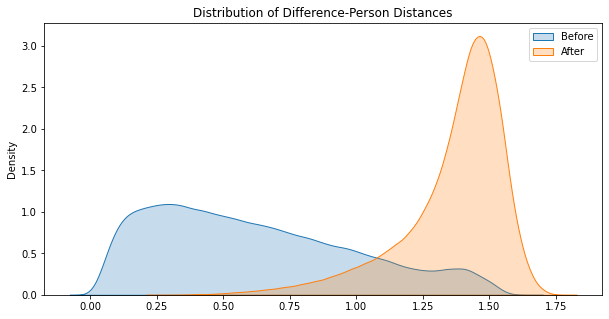

In [20]:
plt.figure(figsize=(10,5))
sns.kdeplot(diff_before, label='Before', shade=True)
sns.kdeplot(diff_after, label='After', shade=True)
plt.title("Distribution of Difference-Person Distances")
plt.legend()
plt.show()

### Boxplot comparison

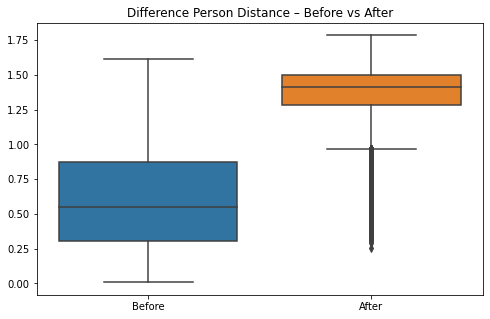

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[diff_before, diff_after])
plt.xticks([0,1], ['Before', 'After'])
plt.title("Difference Person Distance – Before vs After")
plt.show()
